# Jev / TypeSafe API - proof of concept

A small end-to-end POC for the [TypeSafe](https://docs.typesafe.ai/api) evaluation API.

**What Jev is.** TypeSafe exposes a single evaluation endpoint, `POST /v1/systemone`. You send it
some `state` (the content you want judged) plus a map of **typed questions**, and it returns a
structured answer per question. `jev-latest` is the model that serves those requests - so a
"Jev call" is just a request to `/v1/systemone` with `"model": "jev-latest"`.

The point of the typed-question design is that you never parse free text: you ask a `noul`
(yes/no), a `choice` (pick one), or a `score` (rubric rating), and you get back a number or an
enum value with a confidence attached.

**What this notebook covers**

1. A minimal client with bearer auth and exponential backoff on `429` / `529`
2. One call per question type, then all three in a single call
3. A batch evaluation over a small synthetic support-ticket set
4. Flattening the answers into a `DataFrame`, charting them, and tracking token usage

> The key is read from `../../config.json` under `JEV_API_KEY` - the same pattern the other
> notebooks in this repo use.

## 1. Setup

In [1]:
# !pip install requests pandas matplotlib

In [2]:
import json
import os
import random
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests

Matplotlib is building the font cache; this may take a moment.


The API authenticates with a bearer token. Following the convention used elsewhere in this repo,
the key is read from `../../config.json` (which lives outside the repo, so it is never committed)
under the `JEV_API_KEY` entry.

In [3]:
with open("../../config.json") as f:
    config = json.load(f)

for key, value in config.items():
    os.environ[key] = value

API_KEY = os.environ["JEV_API_KEY"]

BASE_URL = "https://api.typesafe.ai"
EVAL_ENDPOINT = f"{BASE_URL}/v1/systemone"
MODEL = "jev-latest"

## 2. A minimal Jev client

The request body has exactly three required fields:

| Field | Type | Meaning |
| --- | --- | --- |
| `state` | string / object / array | the content being evaluated |
| `model` | string | `"jev-latest"` |
| `questions` | map | question id -> typed question object |

The documented failure modes are `401` (bad key), `422` (validation), `429` (rate limit) and
`529` (overloaded). Only the last two are worth retrying, and the docs ask for exponential
backoff - so that is the one piece of real logic in the client.

In [4]:
RETRYABLE = {429, 529}


class JevError(RuntimeError):
    """Raised for a non-retryable API failure."""

    def __init__(self, status_code, body):
        self.status_code = status_code
        self.body = body
        super().__init__(f"TypeSafe API returned {status_code}: {body}")


def jev_call(state, questions, model=MODEL, max_retries=5, timeout=60):
    """Send one evaluation request to /v1/systemone and return the parsed response."""
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }
    payload = {"state": state, "model": model, "questions": questions}

    for attempt in range(max_retries + 1):
        response = requests.post(EVAL_ENDPOINT, headers=headers, json=payload, timeout=timeout)

        if response.status_code == 200:
            return response.json()

        if response.status_code in RETRYABLE and attempt < max_retries:
            # honour Retry-After when the server sends one, otherwise back off exponentially
            retry_after = response.headers.get("Retry-After")
            delay = float(retry_after) if retry_after else min(2**attempt, 30)
            time.sleep(delay + random.uniform(0, 0.5))
            continue

        raise JevError(response.status_code, response.text)

    raise JevError(response.status_code, "retries exhausted")

### Question builders

Each question type shapes `criteria` differently, which is easy to get wrong by hand:

- **noul** - `criteria` is optional, a map with `true` / `false` keys describing each side
- **choice** - `criteria` is a **required** map of `option_key -> description` (description may be `null`)
- **score** - `criteria` is a **required** list of rubric levels, at least two, index = the score

Small helpers keep the call sites readable and the shapes correct.

In [5]:
def noul(instructions, when_true=None, when_false=None):
    """Yes/no question. The answer comes back as a 0-1 float."""
    question = {"type": "noul", "instructions": instructions}
    criteria = {}
    if when_true is not None:
        criteria["true"] = when_true
    if when_false is not None:
        criteria["false"] = when_false
    if criteria:
        question["criteria"] = criteria
    return question


def choice(instructions, options):
    """Single selection. `options` maps each option key to a description (or None)."""
    return {"type": "choice", "instructions": instructions, "criteria": options}


def score(instructions, levels):
    """Rubric rating. `levels` is an ordered list; the index of a level is its score."""
    if len(levels) < 2:
        raise ValueError("a score question needs at least two criteria levels")
    return {"type": "score", "instructions": instructions, "criteria": levels}

## 3. The first Jev call

Start with the simplest possible request: one piece of text, one yes/no question.

In [6]:
ticket = (
    "I have been charged twice for the same annual subscription and the second charge "
    "still has not been refunded after two weeks. This is the third time I am writing "
    "about it and nobody has replied."
)

response = jev_call(
    state=ticket,
    questions={
        "is_billing_issue": noul(
            "Is this message about a billing or payment problem?",
            when_true="Charges, refunds, invoices, subscriptions or pricing.",
            when_false="Anything else - bugs, feature requests, general questions.",
        )
    },
)

print(json.dumps(response, indent=2))

{
  "model": "jev-1.13.0",
  "answers": {
    "is_billing_issue": {
      "type": "noul",
      "noul": 0.99
    }
  },
  "usage": {
    "input_tokens": 352,
    "output_tokens": 24
  }
}


The response is a map keyed by your own question ids, so you read answers back by the same name
you asked them under. A `noul` answer is a single 0-1 float - it is a degree of belief, not a
hard boolean, so compare it against a threshold you pick.

In [7]:
answer = response["answers"]["is_billing_issue"]

print(f"noul value : {answer['noul']:.2f}")
print(f"billing?   : {answer['noul'] > 0.5}")
print(f"tokens     : {response['usage']}")

noul value : 0.99
billing?   : True
tokens     : {'input_tokens': 352, 'output_tokens': 24}


## 4. All three question types in one call

A single call can carry as many questions as you like, which is what makes this cheap to use as
an eval layer - one pass over the content answers the whole rubric.

In [8]:
TICKET_QUESTIONS = {
    "is_billing_issue": noul(
        "Is this message about a billing or payment problem?",
        when_true="Charges, refunds, invoices, subscriptions or pricing.",
        when_false="Anything else - bugs, feature requests, general questions.",
    ),
    "category": choice(
        "Which team should own this ticket?",
        {
            "billing": "Charges, refunds, invoices, subscriptions.",
            "technical": "Bugs, errors, outages, broken functionality.",
            "account": "Login, access, permissions, profile changes.",
            "feedback": "Feature requests, praise or general commentary.",
        },
    ),
    "urgency": score(
        "How urgently does this ticket need a human response?",
        [
            "No urgency - informational, no reply strictly needed.",
            "Low - a reply within the week is fine.",
            "Medium - should be answered within a day.",
            "High - money or access is blocked, answer within hours.",
        ],
    ),
}

response = jev_call(state=ticket, questions=TICKET_QUESTIONS)
print(json.dumps(response, indent=2))

{
  "model": "jev-1.13.0",
  "answers": {
    "is_billing_issue": {
      "type": "noul",
      "noul": 0.99
    },
    "category": {
      "type": "choice",
      "choice": "billing",
      "confidence": 1.0,
      "probabilities": {
        "account": 0.0,
        "billing": 1.0,
        "technical": 0.0,
        "feedback": 0.0
      }
    },
    "urgency": {
      "type": "score",
      "score": 2.6,
      "confidence": 0.6,
      "legend": {
        "0": "No urgency - informational, no reply strictly needed.",
        "1": "Low - a reply within the week is fine.",
        "2": "Medium - should be answered within a day.",
        "3": "High - money or access is blocked, answer within hours."
      },
      "probabilities": {
        "0": 0.0,
        "1": 0.0,
        "2": 0.4,
        "3": 0.6
      }
    }
  },
  "usage": {
    "input_tokens": 541,
    "output_tokens": 80
  }
}


Each answer type carries different fields, and the extras are the useful part:

- `choice` returns the picked key plus `probabilities` across all options and a `confidence`
- `score` returns a **float** (it is a probability-weighted blend of the levels, so `1.6` is a real
  answer, not a rounding bug) plus the `legend`, per-level `probabilities` and a `confidence`

Those confidences are what you route on: send the low-confidence tail to a human instead of
trusting every verdict equally.

In [9]:
def flatten_answers(response):
    """Turn the answers map into one flat dict, one prefix per question id."""
    flat = {}
    for question_id, answer in response["answers"].items():
        kind = answer["type"]
        flat[question_id] = answer[kind]
        if "confidence" in answer:
            flat[f"{question_id}_confidence"] = answer["confidence"]
    return flat


flatten_answers(response)

{'is_billing_issue': 0.99,
 'category': 'billing',
 'category_confidence': 1.0,
 'urgency': 2.6,
 'urgency_confidence': 0.6}

## 5. Batch evaluation

The endpoint handles one `state` per call, so a batch is just a loop. A few synthetic tickets
stand in for a real dataset here.

In [10]:
tickets = [
    {
        "ticket_id": "T-1001",
        "text": (
            "I have been charged twice for the same annual subscription and the second "
            "charge still has not been refunded after two weeks."
        ),
    },
    {
        "ticket_id": "T-1002",
        "text": "Love the new dashboard. Any chance of a dark theme at some point?",
    },
    {
        "ticket_id": "T-1003",
        "text": (
            "The export button throws a 500 error every time I pick a date range longer "
            "than a month. Blocking our month-end reporting right now."
        ),
    },
    {
        "ticket_id": "T-1004",
        "text": (
            "Locked out after the SSO migration - the reset link keeps saying my address "
            "is not recognised and I cannot reach my account at all."
        ),
    },
    {
        "ticket_id": "T-1005",
        "text": "Quick question: does the Pro plan include more than five seats?",
    },
    {
        "ticket_id": "T-1006",
        "text": (
            "We were invoiced in USD instead of EUR this quarter. Not urgent, but the "
            "finance team asked me to flag it before the next cycle."
        ),
    },
]

print(f"{len(tickets)} tickets to evaluate")

6 tickets to evaluate


In [11]:
rows = []
total_input_tokens = 0
total_output_tokens = 0

for ticket_row in tickets:
    result = jev_call(state=ticket_row["text"], questions=TICKET_QUESTIONS)

    rows.append({"ticket_id": ticket_row["ticket_id"], **flatten_answers(result)})

    total_input_tokens += result["usage"]["input_tokens"]
    total_output_tokens += result["usage"]["output_tokens"]

results = pd.DataFrame(rows)
results

,ticket_id,is_billing_issue,category,category_confidence,urgency,urgency_confidence
0,T-1001,0.99,billing,1.00,2.20,0.77
1,T-1002,0.01,feedback,1.00,0.51,0.49
2,T-1003,0.02,technical,1.00,2.94,0.94
3,T-1004,0.02,account,0.96,2.99,0.99
4,T-1005,0.41,billing,0.97,0.62,0.38
5,T-1006,0.97,billing,1.00,0.84,0.81


### Where the model is unsure

Confidence is the whole reason to prefer a typed answer over a parsed string - it gives you a
defensible place to draw the human-review line.

In [12]:
REVIEW_THRESHOLD = 0.6

needs_review = results[
    (results["category_confidence"] < REVIEW_THRESHOLD)
    | (results["urgency_confidence"] < REVIEW_THRESHOLD)
]

print(f"{len(needs_review)} of {len(results)} tickets fall below the confidence threshold")
needs_review

2 of 6 tickets fall below the confidence threshold


,ticket_id,is_billing_issue,category,category_confidence,urgency,urgency_confidence
1,T-1002,0.01,feedback,1.00,0.51,0.49
4,T-1005,0.41,billing,0.97,0.62,0.38


## 6. What the batch looks like

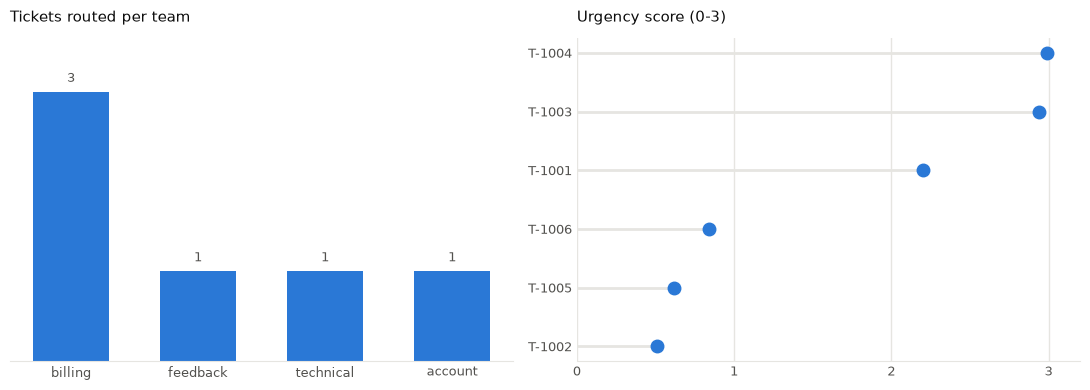

In [13]:
BLUE = "#2a78d6"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e6e5e1"

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4))

# --- routing: how many tickets land on each team ---
counts = results["category"].value_counts()
ax_left.bar(counts.index, counts.values, color=BLUE, width=0.6)
for x, value in enumerate(counts.values):
    ax_left.text(
        x,
        value + 0.08,
        str(value),
        ha="center",
        va="bottom",
        color=TEXT_SECONDARY,
        fontsize=9,
    )
ax_left.set_title("Tickets routed per team", color=TEXT_PRIMARY, fontsize=11, loc="left", pad=12)
ax_left.set_ylim(0, counts.max() + 0.6)
ax_left.set_yticks([])

# --- urgency: the score is continuous, so plot it as a scale, not as buckets ---
ordered = results.sort_values("urgency")
ax_right.hlines(y=ordered["ticket_id"], xmin=0, xmax=ordered["urgency"], color=GRID, linewidth=2)
ax_right.plot(ordered["urgency"], ordered["ticket_id"], "o", color=BLUE, markersize=9, linestyle="none")
ax_right.set_title("Urgency score (0-3)", color=TEXT_PRIMARY, fontsize=11, loc="left", pad=12)
ax_right.set_xlim(0, 3.2)
ax_right.set_xticks([0, 1, 2, 3])
ax_right.xaxis.grid(True, color=GRID, linewidth=1)
ax_right.set_axisbelow(True)

for ax in (ax_left, ax_right):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=9, length=0)

fig.tight_layout()
plt.show()

## 7. Usage

Every response reports its own token counts, so the cost of an eval run is measurable rather than
estimated. Worth logging per run once this is more than a POC.

In [14]:
print(f"calls          : {len(results)}")
print(f"input tokens   : {total_input_tokens:,}")
print(f"output tokens  : {total_output_tokens:,}")
print(f"avg in / call  : {total_input_tokens / len(results):,.0f}")

calls          : 6
input tokens   : 3,155
output tokens  : 480
avg in / call  : 526


## Notes and next steps

What this POC deliberately leaves out, in rough priority order:

- **Concurrency.** The batch is a serial loop. A thread pool over `jev_call` is the obvious next
  step, and the backoff already in the client is what makes that safe under `429`s.
- **Structured `state`.** `state` accepts an object or an array, not just a string, so a ticket
  could be sent as `{"subject": ..., "body": ..., "history": [...]}` and the questions could
  refer to those parts. Worth testing whether that beats flattening to text.
- **Agreement with humans.** None of these verdicts have been checked against labels. Before
  trusting the confidence threshold, run a labelled slice and see where the model and the
  reviewers actually disagree.
- **Caching.** Re-evaluating unchanged content is pure cost; key a cache on
  `hash(state + questions + model)`.